#***Processing***

In [1]:
!pip install Keras
!pip install tensorflow-addons
!pip install opendatasets
!pip install tensorflow-hub

import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda #....
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D #....
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 30.9 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.3.0
    Uninstalling typeguard-4.3.0:
      Successfully uninstalled typeguard-4.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.3.1 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/Dragon Fruit Quality Grading Dataset.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Dragon Fruit Quality Grading Dataset/Augmented Dataset/Defect Dragon Fruit/Defect_Dragon_Augmented_Data1657.jpg  
  inflating: Dragon Fruit Quality Grading Dataset/Augmented Dataset/Defect Dragon Fruit/Defect_Dragon_Augmented_Data1658.jpg  
  inflating: Dragon Fruit Quality Grading Dataset/Augmented Dataset/Defect Dragon Fruit/Defect_Dragon_Augmented_Data1659.jpg  
  inflating: Dragon Fruit Quality Grading Dataset/Augmented Dataset/Defect Dragon Fruit/Defect_Dragon_Augmented_Data1660.jpg  
  inflating: Dragon Fruit Quality Grading Dataset/Augmented Dataset/Defect Dragon Fruit/Defect_Dragon_Augmented_Data1661.jpg  
  inflating: Dragon Fruit Quality Grading Dataset/Augmented Dataset/Defect Dragon Fruit/Defect_Dragon_Augmented_Data1662.jpg  
  inflating: Dragon Fruit Quality Grading Dataset/Augmented Dataset/Defect Dragon Fruit/Defect_Dragon_Augmented_Data1663.jpg  
  inflating: Dragon Fruit Quality Grading Dataset/Augmented 

In [4]:
# prompt: image counts of each folders and subfolders

import os

def count_images(root_directory):
  """
  Counts the number of images in a directory and its subdirectories.

  Args:
    root_directory: The root directory to count images in.

  Returns:
    A dictionary where the keys are the subdirectories and the values are the number of images in each subdirectory.
  """

  image_counts = {}

  for subdirectory in os.listdir(root_directory):
    subdirectory_path = os.path.join(root_directory, subdirectory)

    if os.path.isdir(subdirectory_path):
      image_count = 0

      for file_name in os.listdir(subdirectory_path):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
          image_count += 1

      image_counts[subdirectory] = image_count

  return image_counts

# Example usage
root_directory = '/content/Dragon Fruit Quality Grading Dataset/Original Dataset'
image_counts = count_images(root_directory)

for subdirectory, count in image_counts.items():
  print(f"Subdirectory: {subdirectory}, Image count: {count}")


Subdirectory: Defect Dragon Fruit, Image count: 754
Subdirectory: Fresh Dragon Fruit, Image count: 898


In [5]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = "/content/Dragon Fruit Quality Grading Dataset/Original Dataset"

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['Defect Dragon Fruit', 'Fresh Dragon Fruit']


In [6]:
# prompt: show image height and width

# Assuming 'image_path' is the path to your image
image_path = '/content/Dragon Fruit Quality Grading Dataset/Original Dataset/Defect Dragon Fruit/Defect_Dragon_Original_Data0001.jpg'  # Replace with the actual path
img = image.load_img(image_path)
width, height = img.size
print("Image Width:", width)
print("Image Height:", height)


Image Width: 800
Image Height: 800


In [7]:
from PIL import Image
import os

def resize_images(input_folder, output_folder, target_size=(128, 128)):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through all subfolders in the input folder
    for subfolder in os.listdir(input_folder):
        subfolder_path = os.path.join(input_folder, subfolder)
        if os.path.isdir(subfolder_path):  # Check if it's a directory
            output_subfolder = os.path.join(output_folder, subfolder)
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)
            # Loop through all files in the subfolder
            for filename in os.listdir(subfolder_path):
                # Check if the file is an image
                if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                    # Open the image file
                    with Image.open(os.path.join(subfolder_path, filename)) as img:
                        # Resize the image
                        resized_img = img.resize(target_size)
                        # Save the resized image to the output folder
                        resized_img.save(os.path.join(output_subfolder, filename))

# Specify the input and output folders
input_folder = "/content/Dragon Fruit Quality Grading Dataset/Original Dataset"
output_folder = '/content/resize'

# Call the function to resize images
resize_images(input_folder, output_folder)

In [10]:
base_dir = "/content/resize"

In [11]:
import os
import cv2

def invert_colors(input_folder, output_folder):
    # Iterate through all files and folders recursively
    for root, dirs, files in os.walk(input_folder):
        for file in files:
            # Check if the file is an image
            if file.lower().lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                # Create input and output file paths
                input_image_path = os.path.join(root, file)
                output_image_path = os.path.join(output_folder, os.path.relpath(input_image_path, input_folder))

                # Read the image
                image = cv2.imread(input_image_path)

                # Invert the colors
                inverted_image = ~image

                # Ensure the output directory exists
                os.makedirs(os.path.dirname(output_image_path), exist_ok=True)

                # Save the inverted image
                cv2.imwrite(output_image_path, inverted_image)

# Example usage:
input_folder = "/content/resize"
output_folder = "/content/Invert"
invert_colors(input_folder, output_folder)


In [12]:
base_dir = "/content/Invert"

In [13]:
import numpy as np
import sys

# Monkey-patch numpy to use np.bool_
sys.modules['numpy'].bool = np.bool_

import os
import random
from tqdm import tqdm
from PIL import Image
import imgaug.augmenters as iaa

def augment_image(image, augmenter):
    image_np = np.array(image)
    augmented_image_np = augmenter(image=image_np)
    augmented_image = Image.fromarray(augmented_image_np)
    return augmented_image

def augment_images(source_directory, output_directory, target_count):
    # Define the augmentation pipeline using imgaug
    augmenter = iaa.Sequential([
        iaa.SomeOf((1, 4), [
            iaa.Fliplr(0.5),  # horizontal flips
            iaa.Affine(rotate=(-10, 10)),  # rotations
            iaa.Affine(scale=(0.8, 1.2)),  # zoom
            iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),  # translations
            iaa.AdditiveGaussianNoise(scale=(10, 20)),  # Gaussian noise
            iaa.Multiply((0.8, 1.2)),  # brightness
            iaa.LinearContrast((0.8, 1.2))  # contrast
        ])
    ])

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc=f"Augmenting images in {source_directory}"):
        img_path = os.path.join(source_directory, filename)
        img = Image.open(img_path)

        # Save the original image to the output directory
        img.save(os.path.join(output_directory, f'orig_{filename}'))

        # Generate augmented images
        for i in range(images_per_original):
            augmented_image = augment_image(img, augmenter)
            augmented_image.save(os.path.join(output_directory, f'aug_{i}_{filename}'))

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    if len(output_images) > target_count:
        for i in range(len(output_images) - target_count):
            os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete for {source_directory}. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

# Specify the root directory containing subfolders
root_directory = base_dir  # Change this to your actual base directory

# Find the maximum number of images in any class
max_images = 1500
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))])
        if num_images > max_images:
            max_images = num_images

# Iterate through subfolders and augment images to match the maximum count
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=max_images)

Augmenting images in /content/Invert/Defect Dragon Fruit: 100%|██████████| 754/754 [00:03<00:00, 204.08it/s]


Augmentation complete for /content/Invert/Defect Dragon Fruit. Total images in '/content/augmented/Defect Dragon Fruit': 1500


Augmenting images in /content/Invert/Fresh Dragon Fruit: 100%|██████████| 898/898 [00:03<00:00, 285.23it/s]

Augmentation complete for /content/Invert/Fresh Dragon Fruit. Total images in '/content/augmented/Fresh Dragon Fruit': 1500


In [14]:
base_dir="/content/augmented"

In [15]:
import os
import cv2
import numpy as np

# Function to detect outliers using Modified Z-score method with Median Absolute Deviation (MAD)
def detect_outliers_mad(data, threshold=3.5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    modified_z_scores = 0.6745 * (data - median) / mad
    outliers = np.abs(modified_z_scores) > threshold
    return outliers

# Function to handle outliers in an image using Modified Z-score with MAD
def handle_outliers(image):
    # Flatten the image into a 1D array
    flattened_image = image.flatten()
    # Detect outliers using Modified Z-score with MAD
    outliers = detect_outliers_mad(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(outliers, median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(image.shape)
    return cleaned_image

# Root directory
root_dir = base_dir

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers using Modified Z-score with MAD
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)

Processing subfolder: Defect Dragon Fruit
Processing file: orig_Defect_Dragon_Original_Data0346.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/orig_Defect_Dragon_Original_Data0346.jpg
Processing file: orig_Defect_Dragon_Original_Data0008.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/orig_Defect_Dragon_Original_Data0008.jpg
Processing file: aug_0_Defect_Dragon_Original_Data0243.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/aug_0_Defect_Dragon_Original_Data0243.jpg
Processing file: orig_Defect_Dragon_Original_Data0488.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/orig_Defect_Dragon_Original_Data0488.jpg
Processing file: orig_Defect_Dragon_Original_Data0032.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/orig_Defect_Dragon_Original_Data0032.jpg
Processing file: aug_0_Defect_Dragon_Original_Data0448.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/aug_0_Defect_Dragon_Orig

<ipython-input-15-129410934d08>:9: RuntimeWarning: divide by zero encountered in divide
  modified_z_scores = 0.6745 * (data - median) / mad
<ipython-input-15-129410934d08>:9: RuntimeWarning: invalid value encountered in divide
  modified_z_scores = 0.6745 * (data - median) / mad


Streaming output truncated to the last 5000 lines.
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/orig_Defect_Dragon_Original_Data0191.jpg
Processing file: aug_0_Defect_Dragon_Original_Data0008.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/aug_0_Defect_Dragon_Original_Data0008.jpg
Processing file: aug_0_Defect_Dragon_Original_Data0366.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/aug_0_Defect_Dragon_Original_Data0366.jpg
Processing file: aug_0_Defect_Dragon_Original_Data0165.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/aug_0_Defect_Dragon_Original_Data0165.jpg
Processing file: orig_Defect_Dragon_Original_Data0497.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/orig_Defect_Dragon_Original_Data0497.jpg
Processing file: aug_0_Defect_Dragon_Original_Data0344.jpg
Cleaned image saved at: /content/augmented/Defect Dragon Fruit/aug_0_Defect_Dragon_Original_Data0344.jpg
Processing file: aug_0_Defe

In [16]:
len(folders)

2

In [17]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [18]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [19]:

size = 128

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.


In [20]:
test_labels = np.array(test_generator.labels)

In [33]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, BatchNormalization, Dense
from tensorflow.keras.applications import Xception, EfficientNetV2S
from tensorflow.keras.regularizers import l2

class GroupNormalization(layers.Layer):
    def __init__(self, groups=32, **kwargs):
        super(GroupNormalization, self).__init__(**kwargs)
        self.groups = groups

    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],),
                                     initializer='ones', trainable=True)
        self.offset = self.add_weight(name='offset', shape=(input_shape[-1],),
                                      initializer='zeros', trainable=True)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        group_shape = tf.concat([input_shape[:-1], [self.groups, input_shape[-1] // self.groups]], axis=0)
        grouped_inputs = tf.reshape(inputs, group_shape)
        mean, variance = tf.nn.moments(grouped_inputs, [1, 2], keepdims=True)
        normalized_inputs = (grouped_inputs - mean) / tf.sqrt(variance + 1e-5)
        normalized_inputs = tf.reshape(normalized_inputs, input_shape)
        return normalized_inputs * self.scale + self.offset


def create_xception_efficientnetv2s_model(input_shape, num_classes):
    # Load EfficientNetV2S model
    efficientnetv2s_model = EfficientNetV2S(input_shape=input_shape, include_top=False, weights='imagenet')
    efficientnetv2s_model.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # EfficientNetV2S Backbone
    efficientnetv2s_features = efficientnetv2s_model(input_layer)
    efficientnetv2s_features = GlobalAveragePooling2D()(efficientnetv2s_features)

    # Xception Backbone
    xception_backbone = Xception(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
    )
    xception_backbone.trainable = False
    xception_features = xception_backbone(input_layer)
    xception_features = GlobalAveragePooling2D()(xception_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([efficientnetv2s_features, xception_features])

    x = Flatten()(combined_features)
    x = BatchNormalization()(x)

    # Adding L2 regularization to Dense layers
    x = Dense(32, activation='gelu')(x)  # L2 regularization
    x = layers.Dropout(0.5)(x)
    x = BatchNormalization()(x)

    x = Dense(64, activation='gelu')(x)  # L2 regularization
    x = Dense(64, activation='gelu')(x)  # L2 regularization

    x = Dense(128, activation='gelu')(x)  # L2 regularization
    x = layers.Dropout(0.3)(x)
    x = BatchNormalization()(x)

    x = GroupNormalization()(x)

    output_layer = Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model

# Example usage:
input_shape = (128, 128, 3)  # Example input shape
num_classes = 2  # Example number of classes

model = create_xception_efficientnetv2s_model(input_shape, num_classes)
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22            │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ efficientnetv2-s          │ (None, 4, 4, 1280)     │     20,331,360 │ input_layer_22[0][0]   │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ xception (Functional)     │ (None, 4, 4, 2048)     │     20,861,480 │ input_layer_22[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1280)           │              0 │ efficientnetv2-s[0][0] │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 2048)           │              0 │ xception[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_7             │ (None, 3328)           │              0 │ global_average_poolin… │
│ (Concatenate)             │                        │                │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_7 (Flatten)       │ (None, 3328)           │              0 │ concatenate_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_53    │ (None, 3328)           │         13,312 │ flatten_7[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_35 (Dense)          │ (None, 32)             │        106,528 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_19 (Dropout)      │ (None, 32)             │              0 │ dense_35[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_54    │ (None, 32)             │            128 │ dropout_19[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_36 (Dense)          │ (None, 64)             │          2,112 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_37 (Dense)          │ (None, 64)             │          4,160 │ dense_36[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_38 (Dense)          │ (None, 128)            │          8,320 │ dense_37[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_20 (Dropout)      │ (None, 128)            │              0 │ dense_38[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_55    │ (None, 128)            │            512 │ dropout_20[0][0]       │
│ (BatchNormalization) 

 Total params: 41,328,426 (157.66 MB)

 Trainable params: 128,610 (502.38 KB)

 Non-trainable params: 41,199,816 (157.16 MB)

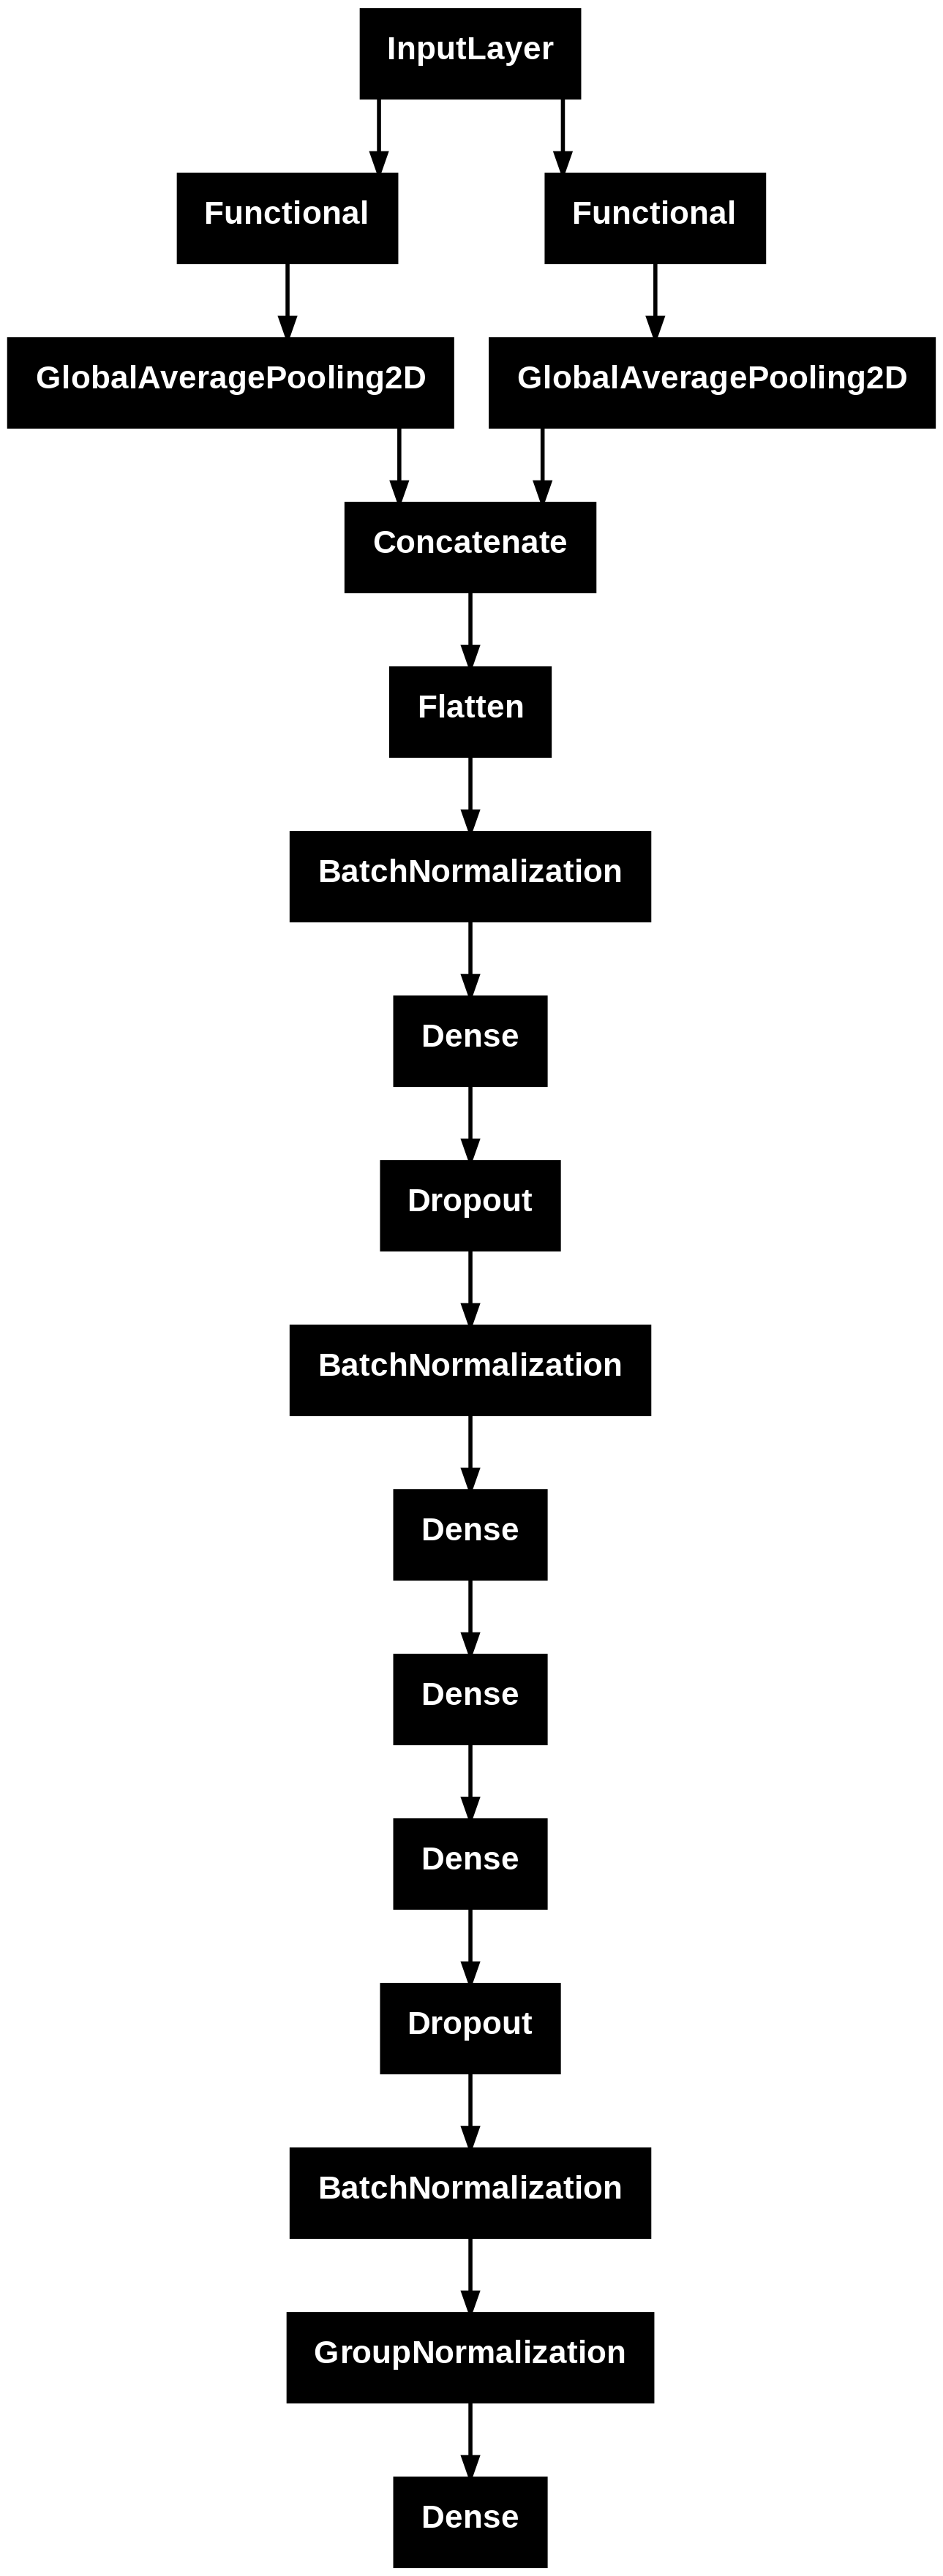

In [34]:
from tensorflow.keras.utils import plot_model
plot_model(model,'model.png')


In [35]:
# input_shape = (224, 224, 3)  # Input image shape
# num_classes = 2  # Number of output classes


model = create_xception_efficientnetv2s_model(input_shape, num_classes)

optim = keras.optimizers.AdamW(
    learning_rate=0.0001,
    weight_decay=0.006,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=True,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=True,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="adamw"
)

from keras.optimizers import Nadam

# optim = Nadam(
#     learning_rate=0.001,
#     beta_1=0.9,
#     beta_2=0.999,
#     epsilon=1e-07,
#     weight_decay=0.006,
#     clipnorm=None,
#     clipvalue=None,
#     global_clipnorm=None,
#     use_ema=False,
#     ema_momentum=0.99,
#     ema_overwrite_frequency=None,
#     name="nadam"
# )

model.compile(
    optimizer=optim,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [36]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.7070 - loss: 0.6088 - val_accuracy: 0.9311 - val_loss: 0.2231 - learning_rate: 1.0000e-04
Epoch 2/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 345ms/step - accuracy: 0.8867 - loss: 0.2833 - val_accuracy: 0.9489 - val_loss: 0.1595 - learning_rate: 1.0000e-04
Epoch 3/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 316ms/step - accuracy: 0.9221 - loss: 0.2071 - val_accuracy: 0.9711 - val_loss: 0.1074 - learning_rate: 1.0000e-04
Epoch 4/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 347ms/step - accuracy: 0.9299 - loss: 0.1802 - val_accuracy: 0.9822 - val_loss: 0.0757 - learning_rate: 1.0000e-04
Epoch 5/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 407ms/step - accuracy: 0.9485 - loss: 0.1430 - val_accuracy: 0.9844 - val_loss: 0.0610 - learning_rate: 1.0000e-04
Epoch 6/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 336ms/step - accuracy: 0.9640 - loss: 0.1192 - val_accuracy: 0.9867 - val_loss: 0.0535 - learning_rate: 1.0000e-04
Epoch 7/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step - accur

In [37]:
test_loss, test_accuracy = model.evaluate(val_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.9961 - loss: 0.0285
Test Loss: 0.0385
Test Accuracy: 0.9933


<Figure size 640x480 with 0 Axes>

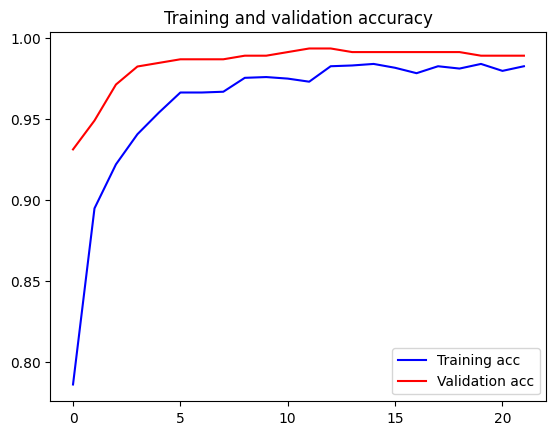

<Figure size 640x480 with 0 Axes>

In [38]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

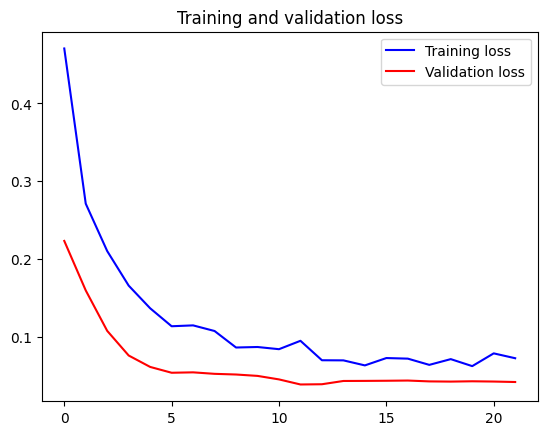

In [39]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step


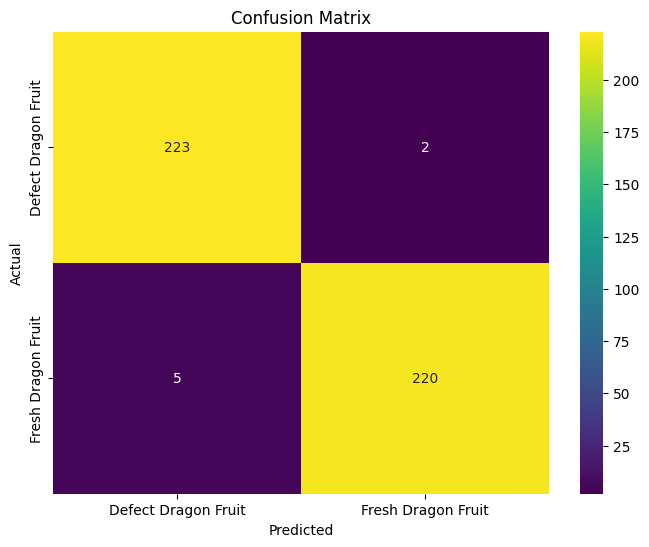

Precision: 0.990990990990991
Recall: 0.9777777777777777
F1 Score: 0.9843400447427293


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step


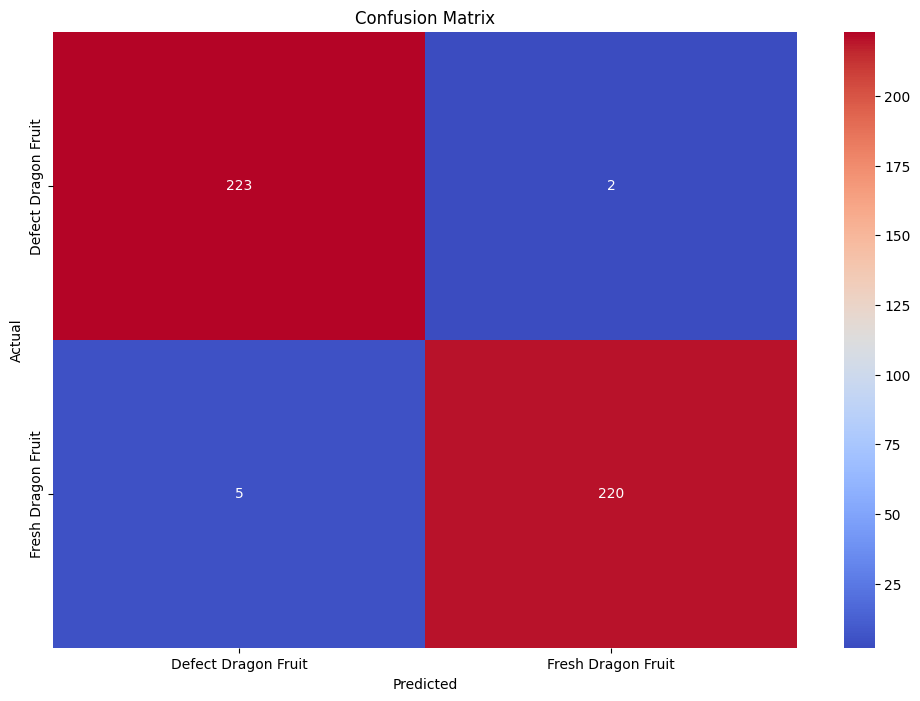

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



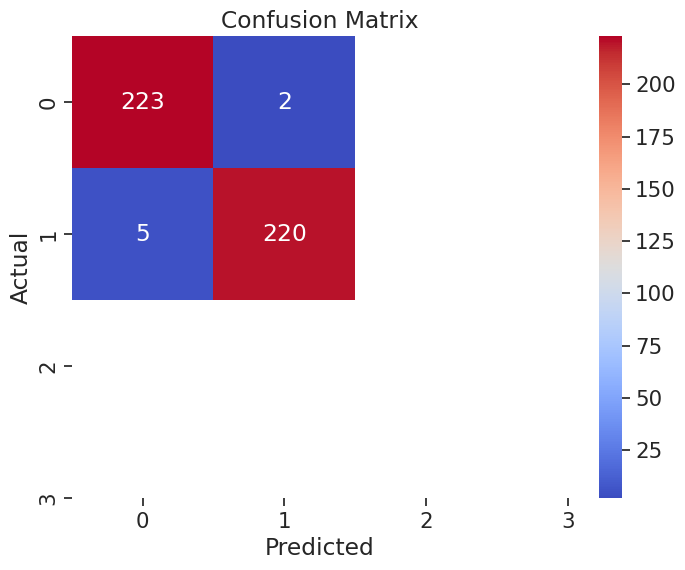

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


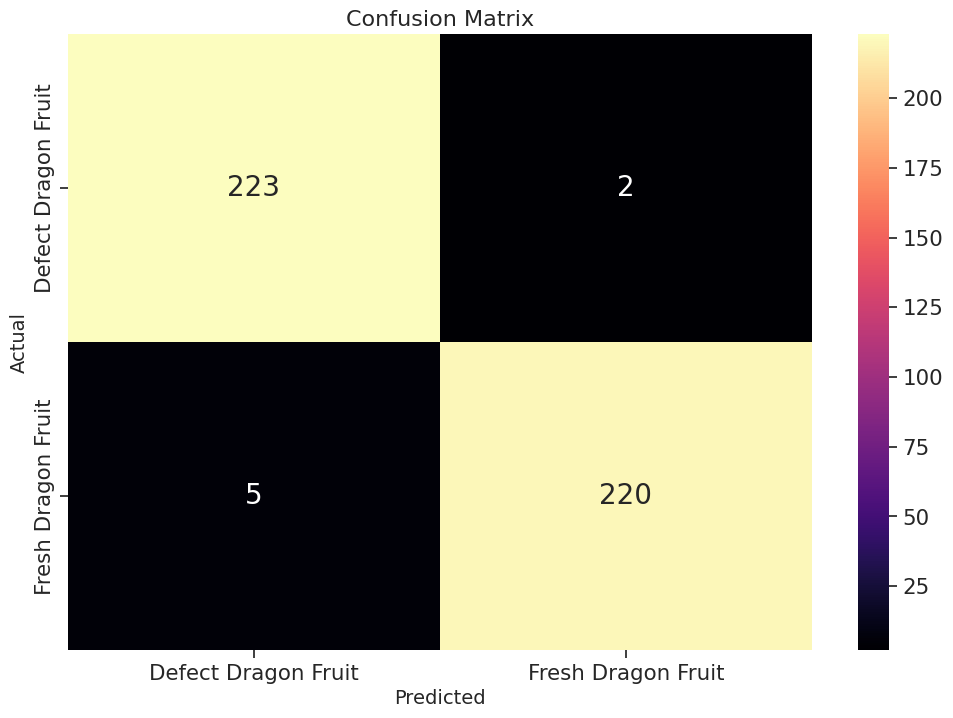

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


In [44]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

In [45]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.98      0.99      0.98       225
           1       0.99      0.98      0.98       225

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming test_labels and predicted_labels are your actual and predicted labels
precision = precision_score(test_labels, predicted_labels, average='weighted')
recall = recall_score(test_labels, predicted_labels, average='weighted')
f1 = f1_score(test_labels, predicted_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.9845305832147937
Recall: 0.9844444444444445
F1 Score: 0.9844437530556913


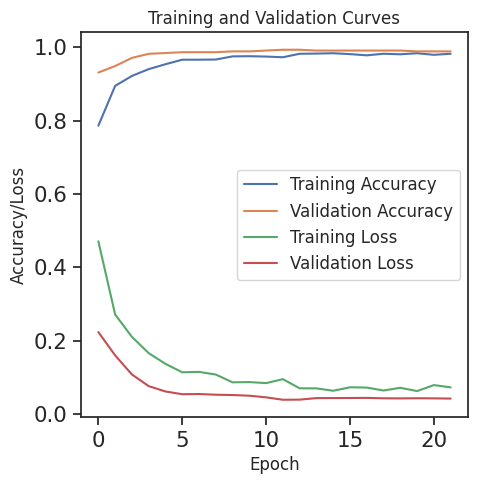

In [47]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progress.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progress.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progress.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progress.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step


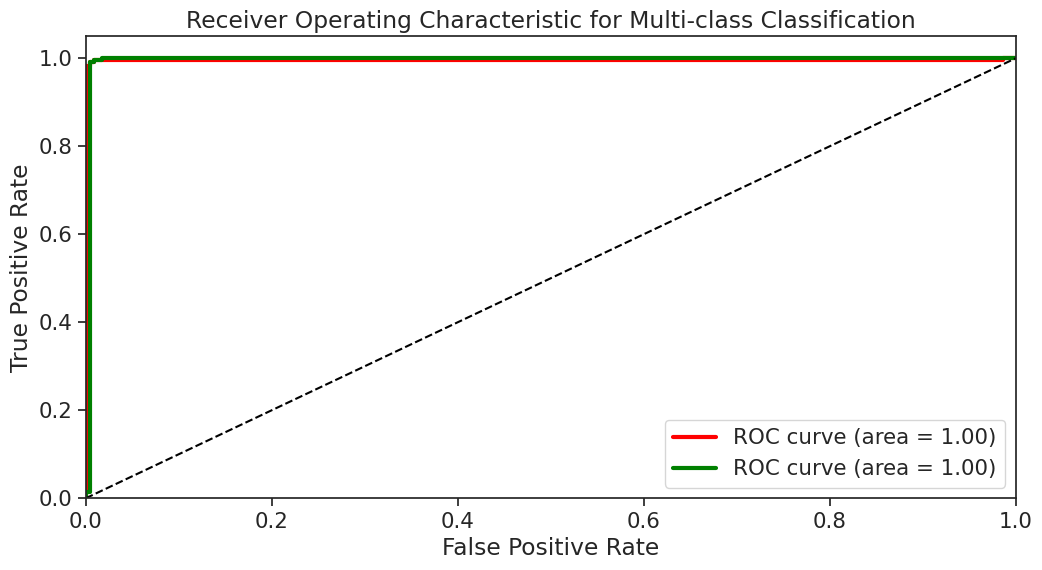

AUC scores:
Class 1: 0.9955358024691358
Class 2: 0.9955358024691359


In [48]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 2  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


In [49]:
# prompt: precison, recall and f1 score using sk learn

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step
Class Defect Dragon Fruit:
Precision: 0.9781
Recall: 0.9911
F1-score: 0.9845

Class Fresh Dragon Fruit:
Precision: 0.9910
Recall: 0.9778
F1-score: 0.9843



In [50]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
Class Defect Dragon Fruit:
Precision: 0.9781
Recall: 0.9911
F1-score: 0.9845

Class Fresh Dragon Fruit:
Precision: 0.9910
Recall: 0.9778
F1-score: 0.9843



In [51]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step
                     precision    recall  f1-score   support

Defect Dragon Fruit       0.98      0.99      0.98       225
 Fresh Dragon Fruit       0.99      0.98      0.98       225

           accuracy                           0.98       450
          macro avg       0.98      0.98      0.98       450
       weighted avg       0.98      0.98      0.98       450



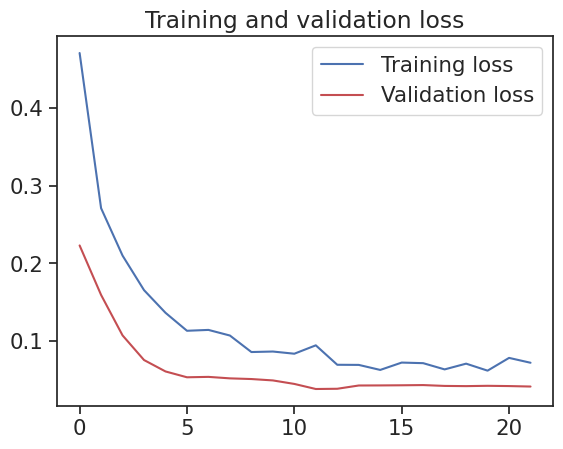

In [52]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

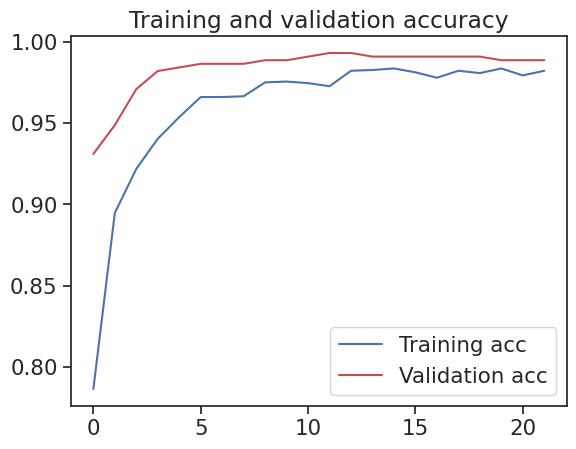

<Figure size 640x480 with 0 Axes>

In [53]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

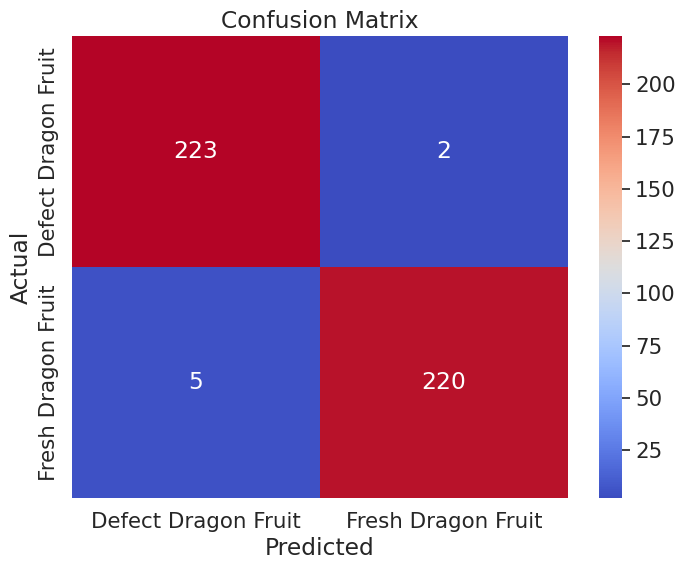

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
#sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step


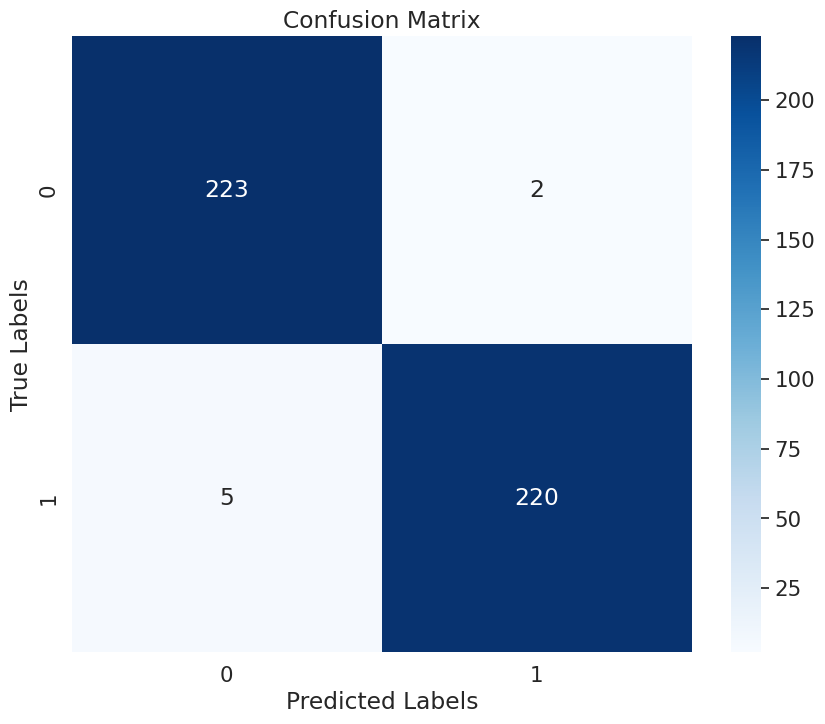

In [55]:
# prompt: give code for confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Get the predicted labels for the test data
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Get the true labels for the test data
true_labels = test_generator.classes

# Create a confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


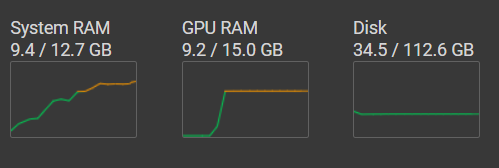